In [1]:
import numpy as np
import random
from scipy.signal import lfilter, butter, square
from IPython.display import Audio
import matplotlib.pyplot as plt

In [2]:
fs = 44100
f0 = 100

In [3]:
formants = {
    "a": {
      "freqs": [620,	1220,	2550,	3300,	4500],
      "bws": [80, 100, 140, 200, 250],
    },
    "e": {
      "freqs": [550, 2000, 2600, 3450, 4700],
      "bws": [50, 80, 100, 150, 200],
    },
    "i": {
      "freqs": [300, 2200, 3000, 3700, 5000],
      "bws": [60, 110, 130, 220, 270],
    },
    "o": {
      "freqs": [500, 800, 2500, 3200, 4300],
      "bws": [50, 80, 80, 150, 200],
    },
    "u": {
      "freqs": [300, 600, 2200, 3000, 4000],
      "bws": [50, 80, 100, 170, 220],
    },
    "y": {
      "freqs": [450, 1400, 2300, 3400, 4500],
      "bws": [70, 110, 120, 200, 250],
    },
    "w": {
        "freqs": [290, 610, 2150],
        "bws": [50, 80, 60],
    },
    "j": {
        "freqs": [260, 2070, 3020],
        "bws": [40, 250, 500],
    },
    "l": {
        "freqs": [310, 1050, 2880],
        "bws": [50, 100, 280],
    },
    "m": {
        "freqs": [250, 1000, 2200],
        "bws": [50, 80, 120],
        "anti_f": 800,
        "anti_bw": 150
    },
    "n": {
        "freqs": [300, 1500, 3500],
        "bws": [60, 90, 130],
        "anti_f": 1000,
        "anti_bw": 160
    },
    "ng": {
        "freqs": [350, 1800, 2800],
        "bws": [60, 100, 130],
        "anti_f": 1500,
        "anti_bw": 200
    },
    "t": {
        "freqs": [400, 1800, 2600],
        "bws": [50, 120, 250],
    },
    "k": {
        "freqs": [300, 2000, 2300],
        "bws": [50, 130, 220],
    },
    "p": {
        "freqs": [200, 800, 2000],
        "bws": [50, 90, 200],
    },
    "r": {
        "freqs": [450, 1100, 2900],
        "bws": [60, 80, 150],
    }
}

In [4]:
def one_band_filter(sig, F, BW, fs=fs):
  T = 1 / fs
  B = 2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
  C = -np.exp(-2 * np.pi * BW * T)
  A = 1 - B - C
  return lfilter([A], [1, -B, -C], sig)

In [5]:
def get_glottal_wave_period(T, fs):
  # функция, возвращающая один период глоттальной волны
  Tp = int(0.4 * T * fs)
  Tn = int(0.16 * T * fs)
  T_ = int(T * fs)

  fp = [3 * (t / Tp) ** 2 - 2 * (t / Tp) ** 3 for t in range(Tp)]
  fn = [1 - ((t - Tp) / Tn) ** 2 for t in range(Tp, Tp + Tn)]
  f0 = [0 for t in range(Tp + Tn, T_)]

  impulse = fp + fn + f0
  return np.array(impulse)

In [6]:
def get_glottal_wave(T, fs, duration, jitter=0.05, shimmer=0.05):
  # функция, возвращающая глоттальную волну нужной длительности
  glottal_wave = []

  period_num = int(duration / T)

  for i in range(period_num):
      T_new = T + T * jitter * random.random()
      new_impulse = get_glottal_wave_period(T_new, fs) * (1 + shimmer * random.random())
      glottal_wave.extend(new_impulse)

  return glottal_wave

In [7]:
def antiformant_filter(sig, F, BW):
    T = 1 / fs
    B = -2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
    C = np.exp(-2 * np.pi * BW * T)
    A = 1
    return lfilter([A, B, C], [1], sig)

In [8]:
nasals = ("m", "n", "ng")

In [9]:
def get_sonorant_sound(phon, fs, f0, duration, make_envelope=False):
    source = get_glottal_wave(1 / f0, fs, duration)

    formant_freqs = formants[phon]["freqs"]
    bws = formants[phon]["bws"]

    result = source
    for freq, bw in zip(formant_freqs, bws):
      result = one_band_filter(result, freq, bw, fs)

    if phon in nasals:
      result = antiformant_filter(result, formants[phon]["anti_f"], formants[phon]["anti_bw"])

    if make_envelope:
      start = int(0.04 * fs)
      end = int(0.05 * fs)

      envelope = np.ones_like(result)
      envelope[:start] = np.linspace(0, 1, start)
      envelope[-end:] = np.linspace(1, 0, end)
      result *= envelope

    return result

In [10]:
def make_morph_sound(first_phon, second_phon, number_of_periods, f0, fs):
  result = []

  morph_formants = []
  morph_bws = []
  first_formants = formants[first_phon]["freqs"]
  sec_formants = formants[second_phon]["freqs"]

  first_bws = formants[first_phon]["bws"]
  sec_bws = formants[second_phon]["bws"]

  for i in range(number_of_periods):
    morph_formants.append([])
    morph_bws.append([])
    for j in range(min(len(first_formants), len(sec_formants))):
      morph_formants[-1].append(first_formants[j] + (i + 1) * (sec_formants[j] - first_formants[j]) / (number_of_periods + 1))
      morph_bws[-1].append(first_bws[j] + (i + 1) * (sec_bws[j] - first_bws[j]) / (number_of_periods + 1))

  for i in range(number_of_periods):
      period = get_glottal_wave_period(1/f0, fs)
      for f, bw, in zip(morph_formants[i], morph_bws[i]):
        period = one_band_filter(period, f, bw, fs)

      result = np.concatenate((result, period))

  return result

In [11]:
def get_stop_sound(phon, stop_duration, burst_duration, fs, f0, is_voiced=False, next_phon=False):
  total_duration = stop_duration + burst_duration
  t = np.linspace(0, total_duration, int(total_duration * fs))

  source = np.concatenate((np.zeros(int(stop_duration * fs)), np.random.normal(0, 1.0, int(burst_duration * fs))))

  if is_voiced:
    voiced = np.sin(2 * np.pi * f0 * t)
    voiced += 0.5 * np.sin(2 * np.pi * 2 * f0 * t)
    voiced += 0.2 * np.sin(2 * np.pi * 3 * f0 * t)
    source += voiced

  if next_phon and phon == "k":
    k_formants = formants[phon]["freqs"]
    k_formants[1] = formants[next_phon]["freqs"][1]
    for f, bw in zip(k_formants, formants[phon]["bws"]):
      source = one_band_filter(source, f, bw, fs)
    return source

  for f, bw in zip(formants[phon]["freqs"], formants[phon]["bws"]):
    source = one_band_filter(source, f, bw, fs)

  if next_phon:
    source = np.concatenate((source, make_morph_sound(phon, next_phon, 3, f0, fs)))

  return source

In [12]:
fricatives = {
    "s": [6000, 2000],
    "sh": [4500, 3000],
    "f": [4500, 7000]
}

In [13]:
def generate_fricative(cons, duration, fs, is_voiced=False, noise_amplitude=0.3, F0=100, make_envelope=True):
  noise = np.random.normal(0, 1, int(duration * fs))

  nyqwist = fs / 2
  low = (fricatives[cons][0] - fricatives[cons][1] / 2) / nyqwist
  high = (fricatives[cons][0] + fricatives[cons][1] / 2) / nyqwist

  b, a = butter(4, [low, high], btype="band")

  result = lfilter(b, a, noise)

  if is_voiced:
    t = np.linspace(0, duration, int(duration * fs))
    voiced_amplitude = 1 - noise_amplitude

    result *= noise_amplitude

    voiced = voiced_amplitude * np.sin(2 * np.pi * f0 * t)
    voiced += 0.5 * voiced_amplitude * np.sin(2 * np.pi * 2 * f0 * t)
    voiced += 0.2 * voiced_amplitude * np.sin(2 * np.pi * 3 * f0 * t)

    result += voiced

  if make_envelope:
    start = int(0.04 * fs)
    end = int(0.05 * fs)

    envelope = np.ones_like(result)
    envelope[:start] = np.linspace(0, 1, start)
    envelope[-end:] = np.linspace(1, 0, end)
    result *= envelope

  return result

In [14]:
def synthesize_trill(duration, f0, fs):
    t = np.linspace(0, duration, int(duration * fs))
    source = get_glottal_wave(1 / f0, fs, duration, jitter=0, shimmer=0)

    f1, f2, f3 = formants["r"]["freqs"]
    bw1, bw2, bw3 = formants["r"]["bws"]

    # Параллельные фильтры
    res1 = one_band_filter(source, f1, bw1, fs)
    res2 = one_band_filter(source, f2, bw2, fs)
    res3 = one_band_filter(source, f3, bw3, fs)

    # Применим фильтры с весами
    output = 0.5 * res1 + 0.3 * res2 + 0.2 * res3

    # Амплитудная модуляция
    # Обычно ее частота от 25 до 30 Гц
    trill_rate_hz = 25
    # Создаем "провалы" в огибающей сигнала там, где происходят смычки (signal.square - это прямоугольный импульс)
    am_envelope = 0.55 + 0.45 * square(2 * np.pi * trill_rate_hz * t, duty=0.4)

    min_length = min(len(output), len(am_envelope))
    output = output[:min_length]
    am_envelope = am_envelope[:min_length]

    # Применяем амплитудную модуляцию
    synthesized_trill = output * am_envelope

    # Нормализуем аудио
    synthesized_trill /= np.max(np.abs(synthesized_trill))

    return synthesized_trill

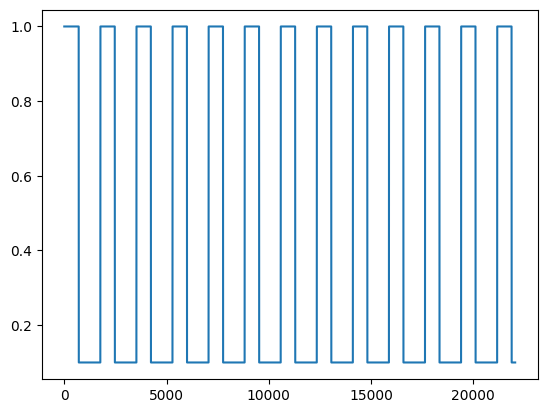

In [25]:
t = np.linspace(0, 0.5, int(0.5 * fs))
plt.plot(0.55 + 0.45 * square(2 * np.pi * 25 * t, duty=0.4))

In [15]:
r = synthesize_trill(1, f0, fs)

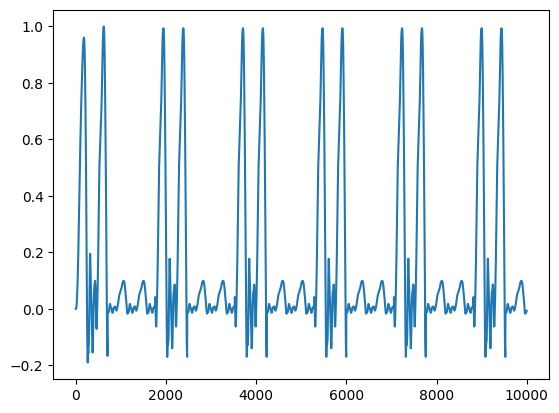

In [16]:
plt.plot(r[:10000])

In [17]:
Audio(r, rate=fs)

Задание. Обновить метод  get_sonorant_sound, добавив в него возможность изменения интонации.

1) Два новых аргумента -  left_f0, right_f0 вместо f0
2) Вместо генерации глоттальной волны, вычислите сколько периодов поместится в сигнал нужной длительности, если ЧОТ принять за среднее арифметическое left_f0 и right_f0
3) Для каждого периода вычислите f0, так, чтобы f0 росла или падала равномерно
4) Сгенерируйте периоды методом get_glottal_wave_period и объедините
5) Дальнейшие шаги как и раньше

In [31]:
def get_sonorant_sound(phon, fs, left_f0, right_f0, duration, make_envelope=False):

    f0 = (left_f0 + right_f0) / 2
    periods_num = int(duration * f0)
    delta = (right_f0 - left_f0) / periods_num
    source = []

    for i in range(periods_num + 1):
      new_freq = left_f0 + i * delta
      source.extend(get_glottal_wave_period(1 / new_freq, fs))

    formant_freqs = formants[phon]["freqs"]
    bws = formants[phon]["bws"]

    result = source
    for freq, bw in zip(formant_freqs, bws):
      result = one_band_filter(result, freq, bw, fs)

    if phon in nasals:
      result = antiformant_filter(result, formants[phon]["anti_f"], formants[phon]["anti_bw"])

    if make_envelope:
      start = int(0.04 * fs)
      end = int(0.05 * fs)

      envelope = np.ones_like(result)
      envelope[:start] = np.linspace(0, 1, start)
      envelope[-end:] = np.linspace(1, 0, end)
      result *= envelope

    return result

In [32]:
a = get_sonorant_sound("a", fs, 100, 200, 0.4)

In [33]:
Audio(a, rate=fs)

Задание. Смоделируйте слово "здравствуйте" по образцу ниже

In [19]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/здравствуйте.wav

--2026-05-27 09:46:47--  https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/%D0%B7%D0%B4%D1%80%D0%B0%D0%B2%D1%81%D1%82%D0%B2%D1%83%D0%B9%D1%82%D0%B5.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77996 (76K) [audio/wav]
Saving to: ‘здравствуйте.wav’

здравствуйте.wav    100%[===================>]  76.17K  --.-KB/s    in 0.01s   

2026-05-27 09:46:48 (5.84 MB/s) - ‘здравствуйте.wav’ saved [77996/77996]



In [53]:
zdrastvujte = np.concatenate((
    0.7 * generate_fricative("s", 0.1, fs, is_voiced=True, make_envelope=True),
    0.05 * get_stop_sound("t", 0.04, 0.005, fs, f0, is_voiced=True, next_phon="r"),
    0.9 * synthesize_trill(0.07, 136, fs),
    get_sonorant_sound("a", fs, 136, 120, 0.09),
    0.5 * generate_fricative("s", 0.05, fs, make_envelope=True),
    0.05 * get_stop_sound("t", 0.03, 0.005, fs, f0),
    0.05 * generate_fricative("f", 0.03, fs, make_envelope=False),
    0.3 * get_sonorant_sound("u", fs, 90, 90, 0.05),
    0.3 * make_morph_sound("u", "i", 2, 90, fs),
    0.3 * get_sonorant_sound("i", fs, 90, 90, 0.05),
    0.05 * get_stop_sound("t", 0.03, 0.005, fs, f0),
    0.3 * generate_fricative("s", 0.05, fs, make_envelope=False),
    0.15 * get_sonorant_sound("i", fs, 80, 80, 0.11, make_envelope=True)
))

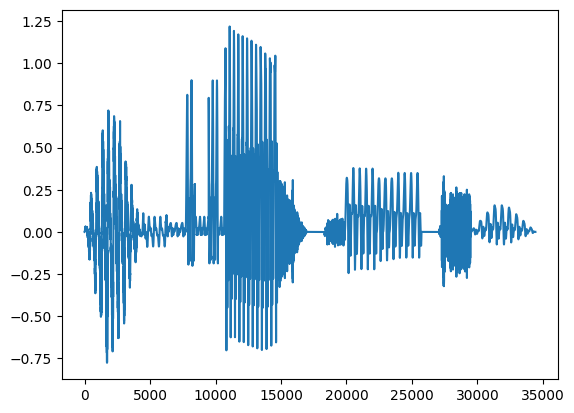

In [54]:
plt.plot(zdrastvujte)

In [55]:
Audio(zdrastvujte, rate=fs)